In [10]:
import sys
from utils import export_mft
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

sys.path.append('..')
from config import DATA_PATH
from pathlib import Path

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

In [2]:
train_files = sorted(TRAIN_PATH.glob("*.WAV")) + sorted(TRAIN_PATH.glob("*.wav"))
print(f"Found {len(train_files)} train files")

sample_files = train_files[:5]  # just grab the first 5 for now
for f in sample_files:
    print(f.name)

Found 20265 train files
DBA_3070_0.WAV
DBA_3070_1.WAV
DBA_3070_10.WAV
DBA_3070_100.WAV
DBA_3070_101.WAV


In [3]:
output_path = export_mft(sample_files[0], output_dir="data/mft_output")
print("Saved to:", output_path)

Saved to: data/mft_output/DBA_3070_0.csv


In [ ]:
df = pd.read_csv(output_path)
df.head(10)

# shows the first 10 rows of the dataframe where the "active" column is equal to 1
df[df["active"] == 1].head(10)

,time_s,frequency_hz,active
17,0.009067,99609.375,1
18,0.009600,99609.375,1
19,0.010133,99609.375,1
20,0.010667,99609.375,1
21,0.011200,99609.375,1
22,0.011733,99609.375,1
23,0.012267,99609.375,1
24,0.012800,99609.375,1
25,0.013333,99609.375,1
26,0.013867,99609.375,1


In [9]:
# starting with 50 files, so its like enough for the PCA to be meaningful
sample_files = train_files[:50]  

trajectory_csvs = []
for f in sample_files:
    try:
        output_path = export_mft(f, output_dir="data/mft_output")
        trajectory_csvs.append(output_path)
    except Exception as e:
        print(f"Failed on {f.name}: {e}")

print(f"Successfully processed {len(trajectory_csvs)} files")

Successfully processed 50 files


In [11]:
def resample_trajectory(csv_path, n_points=100):
    df = pd.read_csv(csv_path)
    active_indices = np.flatnonzero(df["active"].values)

    if len(active_indices) < 2:
        return None  # not enough real signal to resample

    active_freqs = df["frequency_hz"].values[active_indices[0]:active_indices[-1] + 1]

    if np.isnan(active_freqs).any():
        return None  # skip anything with gaps for now, keep it simple

    x_old = np.linspace(0, 1, len(active_freqs))
    x_new = np.linspace(0, 1, n_points)
    f = interp1d(x_old, active_freqs, kind="linear")
    return f(x_new)

resampled_trajectories = []
for csv_path in trajectory_csvs:
    result = resample_trajectory(csv_path)
    if result is not None:
        resampled_trajectories.append(result)

print(f"Resampled {len(resampled_trajectories)} trajectories out of {len(trajectory_csvs)}")

Resampled 38 trajectories out of 50


Data matrix shape: (38, 100)


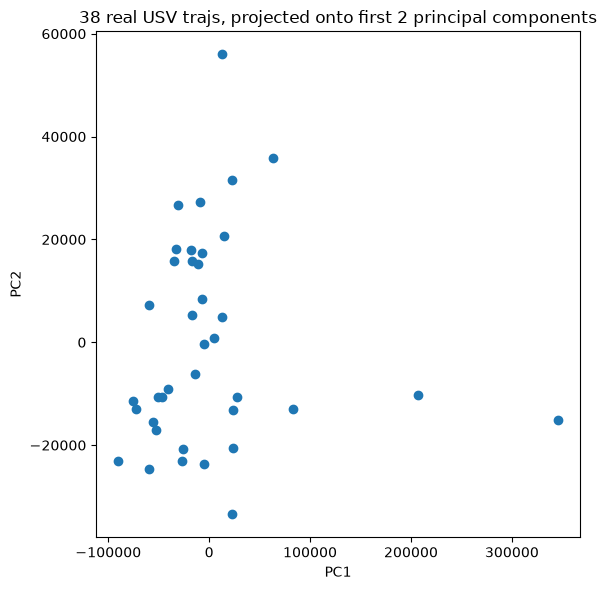

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = np.stack(resampled_trajectories)
print("Data matrix shape:", X.shape)  # should be (38, 100)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(6, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("38 real USV trajs, projected onto first 2 principal components")
plt.tight_layout()
plt.show()

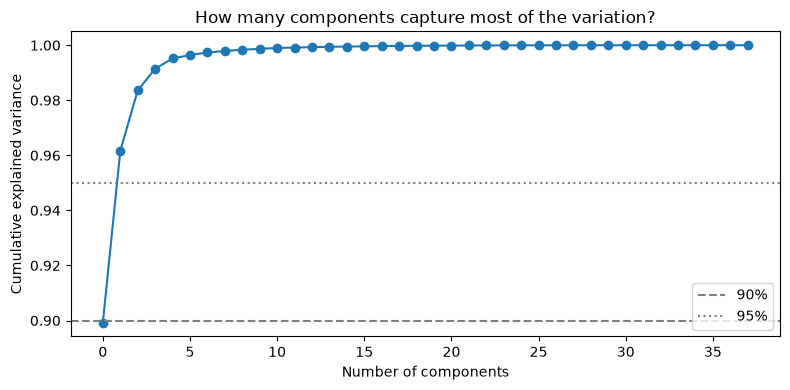

Variance explained by first 5: [0.89923135 0.06238141 0.02196311 0.00787696 0.0037336 ]
Cumulative at 5: 0.9951864237287157


In [13]:
pca_full = PCA()  # no n_components limit, computes all of them
pca_full.fit(X)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(0.90, color='gray', linestyle='--', label='90%')
plt.axhline(0.95, color='gray', linestyle=':', label='95%')
plt.legend()
plt.title("How many components capture most of the variation?")
plt.tight_layout()
plt.show()

print("Variance explained by first 5:", explained_variance[:5])
print("Cumulative at 5:", cumulative_variance[4])

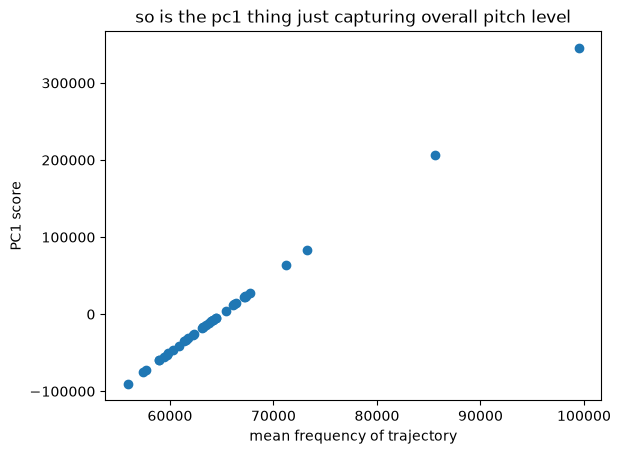

In [14]:
mean_freqs = X.mean(axis=1)  # average frequency of each trajectory
plt.scatter(mean_freqs, X_2d[:, 0])
plt.xlabel("mean frequency of trajectory")
plt.ylabel("PC1 score")
plt.title("so is the pc1 thing just capturing overall pitch level")
plt.show()

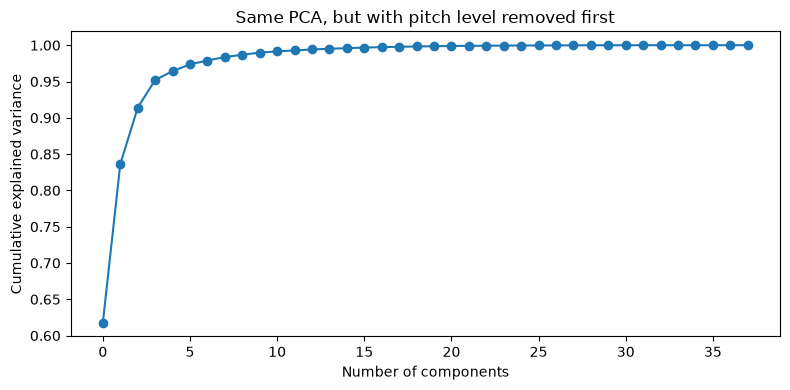

First 10 explained variance ratios (centered):
[0.61786454 0.21825669 0.07787047 0.03807142 0.01219655 0.00942929
 0.00523133 0.0047335  0.0032114  0.00293625]

First 10 cumulative variance (centered):
[0.61786454 0.83612123 0.9139917  0.95206311 0.96425967 0.97368896
 0.97892029 0.98365378 0.98686518 0.98980144]


In [16]:
X_centered = X - X.mean(axis=1, keepdims=True)  # remove each trajectory's own mean pitch

pca_centered = PCA()
pca_centered.fit(X_centered)

cumulative_variance_centered = np.cumsum(pca_centered.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance_centered, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Same PCA, but with pitch level removed first")
plt.tight_layout()
plt.show()

print("First 10 explained variance ratios (centered):")
print(pca_centered.explained_variance_ratio_[:10])

print("\nFirst 10 cumulative variance (centered):")
print(cumulative_variance_centered[:10])